> Archived. This is the Stage 9b 2x2 comparison of D8 against Atlas connectivity, each with DEA and LIST land use. The connectivity axis is now covered by `13_connectivity_resolution.ipynb` (routing resolution) and the land-use axis by Stage 5b. It is kept for the record and reads the shared outputs of Stages 3 to 7.

# Stage 9b — Connectivity x land-use: the 2x2 comparison

**Pairs with Stage 9** (sensitivity). Both connectivity and land-use pressure exist
in two versions (see `README.md`), so this notebook computes relative risk under all
four combinations and reports which axis moves the final map more.

- **Connectivity:** D8 flow routing (main, Stage 3) against the Karst Atlas score (version 2, the earlier frozen score).
- **Land use:** DEA Level-3 land cover (main, Stage 5) against the LIST land-use matrix
  (version 2, `notebooks/05b_landuse_pressure_list.ipynb`).


In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import (add_karst_susceptibility, add_connectivity, add_connectivity_d8, rasterize_max,
                   in_mole_creek_focus, mole_creek_focus_mask, aggregate_pressure_by_system)
from hydro import slope_degrees, slope_risk_multiplier
from landuse_list import MATRIX, load_list_landuse, pressure_raster
from mapping import add_attribution, finish_map

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"

def corr_nonzero(a, b, valid_mask):
    m = valid_mask & ~np.isnan(a) & ~np.isnan(b) & ((a > 0) | (b > 0))
    return np.corrcoef(a[m], b[m])[0, 1]

def named_ranking(risk, karst_only, shape, transform, valid_mask):
    profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
               "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    rows = []
    with MemoryFile() as mem:
        with mem.open(**profile) as dst:
            dst.write(np.where(valid_mask & ~np.isnan(risk), risk, -9999).astype("float32"), 1)
        with mem.open() as src:
            for name, group in karst_only.dropna(subset=["KNAME"]).groupby("KNAME"):
                img, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
                v = img[0]; v = v[v != -9999]
                rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan, "n_px": len(v)})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)


## 1. Mole Creek (25 m)


In [2]:
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_mc_EPSG7855.tif") as src:
    conn_d8 = src.read(1).astype(float)           # main: D8 flow routing, log classes
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    conn_atlas = src.read(1).astype(float)        # version 2: Karst Atlas score
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata; transform = src.transform; shape = dem.shape
    cell = abs(src.transform.a); bounds = src.bounds
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    dea = src.read(1).astype(float); dea_nodata = src.nodata

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
focus = mole_creek_focus_mask(karst_mc, shape, transform)
valid = (dem != dem_nodata) & focus
karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)]

S = intensity / 4.0
intrinsic_d8, intrinsic_atlas = S * conn_d8 / 3.0, S * conn_atlas / 3.0

lu = load_list_landuse(inpath / "LIST_LAND_USE_2021_STATEWIDE" / "list_land_use_2021_statewide.shp",
                        "EPSG:7855", bounds_target=tuple(bounds))
p_list = pressure_raster(lu, MATRIX, shape, transform).astype(float)
top = max(MATRIX.values())
eff_list = aggregate_pressure_by_system(karst_mc, p_list, transform, -1)
eff_dea = aggregate_pressure_by_system(karst_mc, dea, transform, dea_nodata)

# The slope multiplier is part of the frozen formula (R = S x C x P x slope, Stage 6/7) and is
# the same in all four combinations, so the comparison isolates the connectivity and land-use choices.
slope_factor = slope_risk_multiplier(slope_degrees(dem, dem_nodata, cell))

combos = {
    "D8 conn x DEA (main)": np.where(valid, intrinsic_d8 * eff_dea / 3.0 * slope_factor, np.nan),
    "D8 conn x LIST":       np.where(valid & (eff_list >= 0), intrinsic_d8 * eff_list / top * slope_factor, np.nan),
    "Atlas conn x DEA":     np.where(valid, intrinsic_atlas * eff_dea / 3.0 * slope_factor, np.nan),
    "Atlas conn x LIST":    np.where(valid & (eff_list >= 0), intrinsic_atlas * eff_list / top * slope_factor, np.nan),
}
baseline = combos["D8 conn x DEA (main)"]

rows = [{"combination": name, "mean risk": round(np.nanmean(r[valid]), 4),
         "r vs main": round(corr_nonzero(baseline, r, valid), 4)} for name, r in combos.items()]
print(pd.DataFrame(rows).to_string(index=False))

table = named_ranking(baseline, karst_only, shape, transform, valid).set_index("KNAME")[["mean_risk"]].rename(columns={"mean_risk": "D8 x DEA"})
for name in list(combos)[1:]:
    table[name] = named_ranking(combos[name], karst_only, shape, transform, valid).set_index("KNAME")["mean_risk"]
print("\nMean risk by Mole Creek area:")
print(table.round(3).to_string())


         combination  mean risk  r vs main
D8 conn x DEA (main)     0.1386     1.0000
      D8 conn x LIST     0.0897     0.9950
    Atlas conn x DEA     0.1950     0.4964
   Atlas conn x LIST     0.1260     0.4840

Mean risk by Mole Creek area:
                              D8 x DEA  D8 conn x LIST  Atlas conn x DEA  Atlas conn x LIST
KNAME                                                                                      
Mole Creek  (Chudleigh Hill)     0.241           0.198             0.268              0.221
Mole Creek                       0.143           0.091             0.202              0.129
Meander - Western Creek          0.071           0.061             0.089              0.076


### Figure


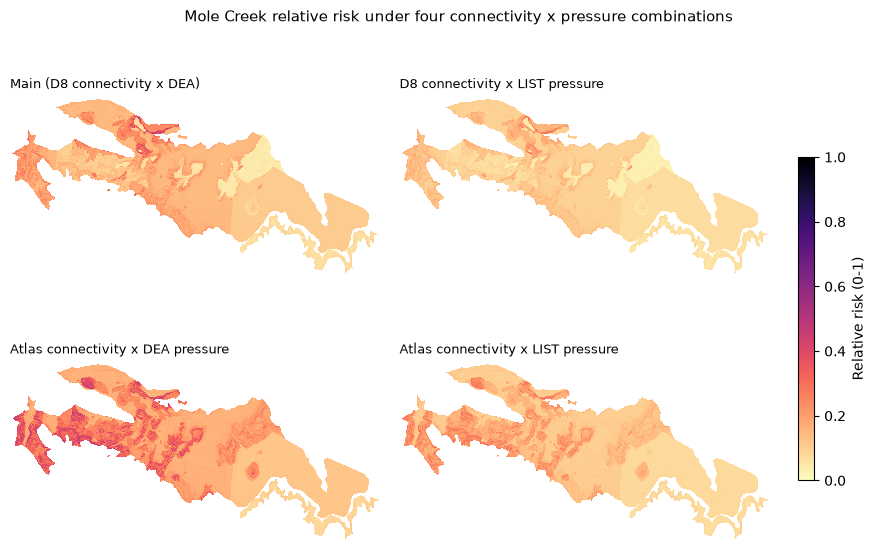

In [3]:
import matplotlib as mpl
cmap = mpl.colormaps["magma_r"].copy(); cmap.set_bad("white")
rows_px, cols_px = np.nonzero(valid)
r0, r1 = max(rows_px.min()-10, 0), min(rows_px.max()+10, valid.shape[0])
c0, c1 = max(cols_px.min()-10, 0), min(cols_px.max()+10, valid.shape[1])
panel_h = 2.6; panel_w = panel_h * ((c1 - c0) / (r1 - r0))

fig, axes = plt.subplots(2, 2, figsize=(panel_w * 2 + 1.2, panel_h * 2 + 0.8), sharex=True, sharey=True,
                          gridspec_kw={"hspace": 0.35, "wspace": 0.05})
labels = {"D8 conn x DEA (main)": "Main (D8 connectivity x DEA)",
          "D8 conn x LIST": "D8 connectivity x LIST pressure",
          "Atlas conn x DEA": "Atlas connectivity x DEA pressure",
          "Atlas conn x LIST": "Atlas connectivity x LIST pressure"}
for ax, (key, title) in zip(axes.ravel(), labels.items()):
    arr = combos[key][r0:r1, c0:c1]
    v = valid[r0:r1, c0:c1]
    masked = np.ma.masked_where(~v | np.isnan(arr), arr)
    im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title, fontsize=9, loc="left")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
fig.colorbar(im, ax=axes, shrink=0.7, pad=0.03, label="Relative risk (0-1)")
fig.suptitle("Mole Creek relative risk under four connectivity x pressure combinations", fontsize=11, y=1.01)
fig.savefig(Path("..") / "figures" / "connectivity_landuse_2x2_mole_creek.png", dpi=200, bbox_inches="tight")
plt.show()


## 2. Statewide (100 m)

Same four combinations at 100 m. Polygons too small for a 100 m cell keep their Atlas score in the D8 version (Stage 7).

In [4]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tdem = src.read(1); tnodata = src.nodata; ttransform = src.transform; tshape = tdem.shape; tcell = abs(src.transform.a)
    land, _ = mask(src, tasmania.geometry, crop=False, nodata=tnodata)
tvalid = land[0] != tnodata

karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas); add_connectivity(karst_tas)
add_connectivity_d8(karst_tas, outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv", scheme="log")
t_int = rasterize_max(karst_tas, "karst_intensity", tshape, ttransform).astype(float)
t_conn_d8 = rasterize_max(karst_tas, "connectivity", tshape, ttransform, dtype="float32").astype(float)
t_conn_atlas = rasterize_max(karst_tas, "connectivity_atlas", tshape, ttransform).astype(float)
tkarst = (t_int > 0) & tvalid
tkarst_only = karst_tas[karst_tas["karst_intensity"] > 0]

tS = t_int / 4.0
tslope = slope_degrees(tdem, tnodata, tcell)
t_intrinsic_d8, t_intrinsic_atlas = tS * t_conn_d8 / 3.0, tS * t_conn_atlas / 3.0

with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    tbase_file = src.read(1).astype(float); trn = src.nodata
tbase_file = np.where(tvalid & (tbase_file != trn), tbase_file, np.nan)

# The saved raster is S x C(D8) x P x slope (Stage 7). Back-solve the effective DEA pressure
# by dividing out S x C x slope, so the other connectivity and the LIST pressure can be swapped in.
tslope_factor = slope_risk_multiplier(tslope)
t_denominator = t_intrinsic_d8 * tslope_factor
t_eff_dea_norm = np.where(t_denominator > 0, tbase_file / np.where(t_denominator > 0, t_denominator, 1), 0.0)

lu_t = load_list_landuse(inpath / "LIST_LAND_USE_2021_STATEWIDE" / "list_land_use_2021_statewide.shp", "EPSG:7855")
t_p_list = pressure_raster(lu_t, MATRIX, tshape, ttransform).astype(float)
t_eff_list = aggregate_pressure_by_system(karst_tas, t_p_list, ttransform, -1)

tcombos = {
    "D8 conn x DEA (main)": tbase_file,
    "D8 conn x LIST":       np.where(tvalid & (t_eff_list >= 0), t_intrinsic_d8 * t_eff_list / top * tslope_factor, np.nan),
    "Atlas conn x DEA":     np.where(tvalid, t_intrinsic_atlas * t_eff_dea_norm * tslope_factor, np.nan),
    "Atlas conn x LIST":    np.where(tvalid & (t_eff_list >= 0), t_intrinsic_atlas * t_eff_list / top * tslope_factor, np.nan),
}
tbaseline = tcombos["D8 conn x DEA (main)"]

rows = [{"combination": name, "mean risk (karst)": round(np.nanmean(r[tkarst]), 4),
         "r vs main": round(corr_nonzero(tbaseline, r, tvalid), 4)} for name, r in tcombos.items()]
print(pd.DataFrame(rows).to_string(index=False))

ttable = named_ranking(tbaseline, tkarst_only, tshape, ttransform, tvalid).set_index("KNAME")[["mean_risk"]].rename(columns={"mean_risk": "D8 x DEA"})
for name in list(tcombos)[1:]:
    ttable[name] = named_ranking(tcombos[name], tkarst_only, tshape, ttransform, tvalid).set_index("KNAME")["mean_risk"]
print("\nTop 10 named areas:")
print(ttable.sort_values("D8 x DEA", ascending=False).head(10).round(3).to_string())


         combination  mean risk (karst)  r vs main
D8 conn x DEA (main)             0.1053     1.0000
      D8 conn x LIST             0.0554     0.8270
    Atlas conn x DEA             0.1417     0.6335
   Atlas conn x LIST             0.0737     0.5638



Top 10 named areas:
                                  D8 x DEA  D8 conn x LIST  Atlas conn x DEA  Atlas conn x LIST
KNAME                                                                                          
Geilston Bay                         0.416           0.270             0.277              0.180
Vinegar Hill                         0.378           0.227             0.378              0.227
Mt Stanley Creek                     0.302           0.163             0.302              0.163
Gunns Plains                         0.280           0.211             0.276              0.208
Fairview (Redpa) (1 & 2)             0.278           0.174             0.257              0.161
Mole Creek  (Chudleigh Hill)         0.261           0.197             0.290              0.219
Irishtown - Sedgy Creek (3)          0.261           0.168             0.312              0.208
South Pindars                        0.259           0.078             0.323              0.097
Lower Black River -

## Result

All four combinations carry the same slope multiplier and the same susceptibility, so the comparison isolates the connectivity choice and the land-use choice.

**Connectivity is now the larger axis at both scales.** Switching connectivity alone (D8 to Atlas, same DEA pressure) drops the correlation with the main map to r = 0.496 at Mole Creek and r = 0.634 statewide. Switching land use alone (DEA to LIST, same D8 connectivity) gives r = 0.995 at Mole Creek and r = 0.827 statewide. The two changes compound: Atlas connectivity with LIST pressure correlates at r = 0.484 (Mole Creek) and r = 0.564 (statewide) with the main map.

The Atlas score barely varies across Mole Creek (most polygons score 3), so against D8 it mainly changes where risk sits inside each named area, not the order of the three areas, which is the same in all four combinations. Statewide the choice changes which systems lead: Doctors Rocks and South Pindars score higher under the Atlas, and Geilston Bay and Lower Black River - South Forest score higher under D8.

Land-use v2 (LIST) roughly halves mean risk everywhere (natural land scores 1/10 instead of 1/3). That is a level shift, not a ranking one, but it means the fixed 0.2-wide risk classes would need recalibrating if LIST became the default. Atlas connectivity raises mean risk on the karst (0.195 against 0.139 at Mole Creek, 0.142 against 0.105 statewide) because most karst polygons score 3 under the Atlas but sit in the middle D8 classes.